In [1]:
import os

from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langgraph.constants import START
from langgraph.graph import add_messages
from typing import TypedDict, Annotated, Literal

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel

llm = ChatOpenAI(
    model='deepseek-ai/DeepSeek-V3.2',
    base_url=os.environ.get('OPENAI_BASE_URL'),
    api_key=os.environ.get('OPENAI_API_KEY')
)


class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

D:\Work\Langchain-learn-demo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
from langchain_core.tools import create_retriever_tool
from langchain_huggingface import HuggingFaceEmbeddings
from milvus_vector import MilvusVectorSave
from langchain_core.output_parsers import StrOutputParser
from utils.log_utils import log

model_name = "BAAI/bge-small-zh-v1.5"
model_kwargs = {'device': 'cpu'}
encode_kwargs = {'normalize_embeddings': True}  # set True to compute cosine similarity
embedding_model = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs,
    cache_folder="./cache"
)
mv = MilvusVectorSave(embedding_model)
mv.create_connection()
retriever = mv.vector_store_saved.as_retriever(
    search_type='similarity',  # 只返回相似度大于阈值的结果
    search_kwargs={
        'k': 3,
        'ranker_type': 'rrf',
        'ranker_params': {'k': 100},
        'score_threshold': 0.1,
        'filter': {'category': 'Content'}
    }
)
retriever_tool = create_retriever_tool(
    retriever,
    'rag_retriever',
    '搜索并返回关于 ‘半导体和芯片’ 的信息, 内容涵盖：半导体和芯片的封装、测试、光刻胶等'
)


def agent_node(state: AgentState):
    """
    调用智能体模型基于当前状态生成响应。根据问题，
    它会决定使用检索工具检索，或者直接结束。

    参数:
        state (messages): 当前状态

    返回:
        dict: 更新后的状态，包含附加到消息中的智能体响应
    """
    log.info("---调用智能体---")
    messages = state['messages']
    model = llm.bind_tools([retriever_tool])
    response = model.invoke(messages)
    return {"messages": [response]}


def rewrite_prompt(state: AgentState):
    """
    转换查询以生成更好的问题。

    参数:
        state (messages): 当前状态
    返回:
        dict: 包含重述问题的更新后状态
    """
    log.info("---转换查询---")
    messages = state["messages"]
    question = get_last_human_message(messages).content
    msg = [
        HumanMessage(content=f"请将问题转换成更准确更精准的查询：{question}")
    ]
    response = llm.invoke(msg)
    return {"messages": [response]}


def generate(state: AgentState):
    """
    生成答案

    参数:
        state (messages): 当前状态

    返回:
         dict: 包含重述问题的更新后状态
    """
    log.info("---生成答案---")
    messages = state["messages"]
    question = get_last_human_message(messages).content
    last_message = messages[-1]
    prompt = PromptTemplate(
        template="你是一个问答任务助手。请根据以下检索到的上下文内容回答问题。如果不知道的话，请说“不知道”。\n{context}\n问题：{question}\n答案：",
        input_variables=["context", "question"]
    )
    rag_chain = prompt | llm | StrOutputParser()
    return {"messages": rag_chain.invoke({"context": last_message.content, "question": question})}

Loading weights: 100%|██████████| 71/71 [00:00<00:00, 6584.61it/s]
BertModel LOAD REPORT from: BAAI/bge-small-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
from pydantic import Field


# 数据模型
class Grade(BaseModel):
    """相关性检查的二元评分"""

    binary_score: str = Field(description="相关性评分 'yes' 或 'no'")

In [11]:
from typing import List
from langgraph.constants import END
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(AgentState)

workflow.add_node('agent', agent_node)
workflow.add_node('retrieve', ToolNode([retriever_tool]))
workflow.add_node('rewrite', rewrite_prompt)
workflow.add_node('generate', generate)

workflow.add_edge(START, 'agent')
workflow.add_conditional_edges('agent', tools_condition, {
    'tools': 'retrieve',
    END: END
})


def get_last_human_message(messages: List[BaseMessage]) -> HumanMessage:
    # 反向遍历列表，找到最后一个HumanMessage实例
    for message in reversed(messages):
        if isinstance(message, HumanMessage):
            return message
    raise ValueError("No HumanMessage found in the messages list")


def grade_documents(state: AgentState) -> Literal['generate', 'rewrite']:
    """
    判断检索到的文档是否与问题相关。
    参数:
        state (messages): 当前状态
    返回:
        str: 判断结果，文档是否相关
    """
    log.info("---检查document的相关性---")
    llm_with_structured = llm.with_structured_output(Grade)
    prompt = PromptTemplate(
        template="""你是一个评估检索文档与用户问题相关性的评分器。\n
        这是检索到的文档：\n\n {context} \n\n
        这是用户的问题：{question} \n
        如果文档包含与用户问题相关的关键词或语义含义，则评为相关。\n
        给出二元评分 'yes' 或 'no' 来表示文档是否与问题相关。""",
        input_variables=["context", "question"],
    )
    chain = prompt | llm_with_structured
    messages = state["messages"]
    last_message = messages[-1]  # RAG检索的文档
    question = get_last_human_message(messages).content  # 用户问题

    scored_result = chain.invoke({"question": question, "context": last_message.content})
    if scored_result.binary_score == 'yes':
        return 'generate'
    else:
        return 'rewrite'


workflow.add_conditional_edges('retrieve', grade_documents, {
    'generate': 'generate',
    'rewrite': 'rewrite'
})

workflow.add_edge('rewrite', 'agent')
workflow.add_edge('generate', END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

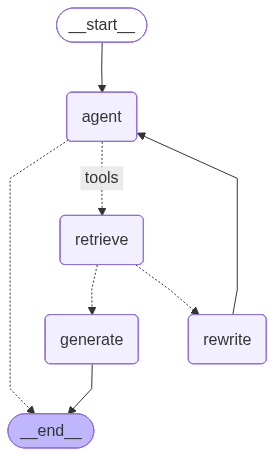

In [15]:
graph

In [28]:
import uuid
from utils.print_utils import _print_event

config = {
    "configurable": {
        # 检查点由session_id访问
        "thread_id": str(uuid.uuid4()),
    }
}

_printed = set()  # set集合，避免重复打印

# 执行工作流
question = "EVU光刻胶是什么"
inputs = {
    "messages": [
        ("user", question),
    ]
}
events = graph.stream(inputs, config=config, stream_mode='values')
# 打印消息
for event in events:
    _print_event(event, _printed)

================================ Human Message =================================

EVU光刻胶是什么
20260413 22:34:44 | MainProcess | MainThread | 3520421884.agent_node:46 | INFO: ---调用智能体---
================================== Ai Message ==================================

我来帮您查找关于"EVU光刻胶"的信息。
Tool Calls:
  rag_retriever (019d8744385082de8ab44100bbcd2523)
 Call ID: 019d8744385082de8ab44100bbcd2523
  Args:
    query: EVU光刻胶
20260413 22:34:48 | MainProcess | MainThread | 2239389885.grade_documents:36 | INFO: ---检查document的相关性---
================================= Tool Message =================================
Name: rag_retriever

半导体制造中光刻胶材料选择的关键因素 -> 不同类型光刻胶的适用场景 I线光刻胶(365nm)：用于成熟制程(>0.35μm) KrF光刻胶(248nm)：适用于0.25-0.13μm节点 ArF光刻胶(193nm)：主流DUV工艺(65-7nm) EUV光刻胶(13.5nm)：7nm以下先进节点 电子束光刻胶：用于掩模版制作和研发验证

EUV光刻胶材料在下一代光刻技术中的关键作用

半导体制造中光刻胶的选择标准 -> 光刻胶的基本定义与功能 光刻胶（Photoresist）是半导体制造中用于光刻工艺的关键材料，其作用是通过光化学反应将掩膜版（Mask）上的图形转移到硅片表面。根据光化学反应特性，光刻胶分为正性光刻胶（Positive Photoresist）和负性光刻胶（Negative Photoresist）两种。正性光刻胶在曝

In [29]:
retriever_tool.invoke("EUV光刻胶")

'EUV光刻胶材料在下一代光刻技术中的关键作用 -> EUV光刻胶的特殊技术挑战 EUV光刻胶面临三大物理限制： 1. 光子吸收效率：13.5nm波长光子能量高达92eV，但硅基材料吸收深度仅约20nm，要求光刻胶薄膜厚度控制在30-50nm范围 2. 二次电子效应：EUV光子撞击光刻胶会产生大量二次电子（Secondary Electrons），导致反应区域扩大，影响分辨率 3. 随机效应（Stochastic Effects）：由于EUV光子数量有限，单个光子引发的化学反应存在统计波动 目前主流研发方向包括： - 化学放大胶（Chemically Amplified Resist, CAR）：通过酸扩散机制实现信号放大 - 金属氧化物胶（Metal-Oxide Resist）：如氧化锡、氧化铪体系，具有高EUV吸收率 - 分子玻璃胶（Molecular Glass Resist）：由定义明确的有机分子构成，减少显影不均匀性\n\nEUV光刻胶材料在下一代光刻技术中的关键作用\n\nEUV光刻胶研发的重要性与7nm以下制程的推动 极紫外光（EUV）光刻技术是半导体制造中一项具有革命性的进展，尤其是在生产7nm及更小制程节点的芯片时。EUV光刻胶的研发成为推进这一技术进步的关键因素，原因主要体现在以下几个方面。 -> 3. EUV光刻胶的创新需求 EUV光刻胶的研发对于实现7nm及更小制程至关重要。由于EUV光的高能量特性，传统的光刻胶在高能量照射下容易导致材料的光化学反应不稳定，从而影响图形的形成。这就需要研发新型的、具有高耐辐射性的光刻胶，以确保在EUV曝光后仍能准确地保留所需的图形结构。此外，EUV光刻胶还需要具备快速显影、优良的分辨率以及良好的抗污染性能，这使得其研发工作面临许多挑战。'

In [30]:
memory.get(config=config)

{'v': 4,
 'ts': '2026-04-13T14:34:57.218669+00:00',
 'id': '1f13745f-1ae1-6cd8-8003-992c5cefa6fd',
 'channel_versions': {'__start__': '00000000000000000000000000000002.0.3029642635559291',
  'messages': '00000000000000000000000000000005.0.8644057773885061',
  'branch:to:agent': '00000000000000000000000000000003.0.8065144724933533',
  'branch:to:retrieve': '00000000000000000000000000000004.0.3758856583393546',
  'branch:to:generate': '00000000000000000000000000000005.0.8644057773885061'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000001.0.5390281493573242'},
  'agent': {'branch:to:agent': '00000000000000000000000000000002.0.3029642635559291'},
  'retrieve': {'branch:to:retrieve': '00000000000000000000000000000003.0.8065144724933533'},
  'generate': {'branch:to:generate': '00000000000000000000000000000004.0.3758856583393546'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='EVU光刻胶是什么', additional